# m19: HD–RF circular correlation — three schemes

Directly pair **session 11 saved TC** with **session 2 RF**, Probe A. Reuse the existing HD Class 3 selection.

1. All Class 3 cells with a defined RF maximum.
2. Class 3 cells with a saved excitatory 2D RF detection.
3. Scheme 2 cells whose `wrap360(HD + RF)` falls in its three most populated polar histogram bins.

RF position means the horizontal coordinate of the **global maximum bin in the native 2D response map**, after occupancy normalization and summing the 0–200 ms response. No horizontal projection, interpolation, smoothing, or additional RF quality filter is applied. The maximum need not lie inside the detection mask; the mask selects cells only.

The saved TC is counterclockwise; negate its preferred angle once to express both HD and RF clockwise. The source file remains unchanged.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

from Utils.hd_rf_schemes import load_peak_pairs, select_schemes
from Utils.hd_rf_circular_regression import fit_circular_conversion, predict_circular_conversion
assert '/home/kai/.virtualenvs/rfmapping' in sys.executable, sys.executable
print(sys.executable)

root = Path('/mnt/senzailab/Kai/#Recording/m19/260827')
hd_file = root / '260827_11/data/tuning_curves/ProbeA/tuning_curves.json'
rf_file = root / '260827_2/data/rfmapping/good/-100_400_1ms/ProbeA/regular_unitsSpikeCounts_260827_2.rfmap'
output = Path('output/hd_rf_schemes/m19_260827_hd11_rf2')
output.mkdir(parents=True, exist_ok=True)
polar_bins = 30
top_n_bins = 3
n_permutations = 10_000
random_seed = 1

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'savefig.facecolor': 'white', 'savefig.transparent': False,
                     'text.color': '#17212b', 'axes.labelcolor': '#17212b',
                     'xtick.color': '#17212b', 'ytick.color': '#17212b',
                     'font.size': 11})

/home/kai/.virtualenvs/rfmapping/bin/python


## Load the saved sources

HD profiles use the existing 30-bin, unsmoothed TC reader. Keep source angles alongside the converted clockwise angles for audit. Undefined peaks are reported instead of silently removed from the source inventory.

In [2]:
# Data-loader settings and selection details are saved with every result.
all_pairs, provenance = load_peak_pairs(hd_file, rf_file, hd_is_clockwise=False)
schemes, selection = select_schemes(all_pairs, n_bins=polar_bins, top_n_bins=top_n_bins)
for name, pairs in schemes.items():
    all_pairs[name] = all_pairs.unit_id.isin(pairs.unit_id)
all_pairs.to_csv(output / 'all_pairs.csv', index=False)
for name, pairs in schemes.items():
    pairs.to_csv(output / f'{name}.csv', index=False)
(output / 'provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')
(output / 'selection_manifest.json').write_text(json.dumps(selection, indent=2) + '\n')
display(all_pairs)

,mouse,date,probe,unit_id,hd_class,hd_native_preferred_deg,hd_preferred_deg,hd_peak_hz,hd_peak_ties,rf_map_present,...,rf_peak_in_saved_2d_mask,rf_finite_bins,rf_zero_bins,rf_missing_bins,hd_plus_rf_deg,peak_valid,exclusion_reason,scheme1,scheme2,scheme3
0,m19,260827,A,75,3,246.0,114.0,6.241669,1,True,...,True,210,0,0,216.0,True,,True,True,False
1,m19,260827,A,104,3,246.0,114.0,29.162758,1,True,...,False,210,0,0,60.0,True,,True,False,False
2,m19,260827,A,124,3,54.0,306.0,82.508166,1,True,...,True,210,0,0,264.0,True,,True,True,False
3,m19,260827,A,134,3,210.0,150.0,35.406474,1,True,...,False,210,0,0,144.0,True,,True,True,True
4,m19,260827,A,135,3,246.0,114.0,69.445128,1,True,...,True,210,0,0,168.0,True,,True,True,True
5,m19,260827,A,136,3,222.0,138.0,84.468833,1,True,...,True,210,0,0,168.0,True,,True,True,True
6,m19,260827,A,146,3,54.0,306.0,4.263487,1,True,...,True,210,2,0,192.0,True,,True,True,False
7,m19,260827,A,147,3,54.0,306.0,58.186910,1,True,...,True,210,0,0,192.0,True,,True,True,False
8,m19,260827,A,170,3,210.0,150.0,39.570711,1,True,...,True,210,0,0,144.0,True,,True,True,True
9,m19,260827,A,177,3,246.0,114.0,25.386285,1,True,...,False,210,0,0,240.0,True,,True,False,False


## Circular correlation and one-offset conversion

Signed Fisher–Lee circular–circular correlation measures the association; it can be negative or positive. Scheme 1 and 2 use a seeded, two-sided permutation test that shuffles cell pairings.

For the conversion, use the simple reversed circular phase map:

\[
\beta=\arg\sum_i e^{\mathrm{i}(HD_i+RF_i)},\qquad
\widehat{RF}_{ego}(h)=\operatorname{wrap}_{180}(\beta-h).
\]

Only **β is fitted**. The conversion slope is **set to −1**, rather than estimated or imposed on the reported correlation. Consequently its predicted allocentric direction is β. This is a one-offset conversion, without a local kernel or additional curve-shape parameters.

**Scheme 3 is selected using HD + RF itself.** Its correlation and fitted error describe that selected subset; they are not independent evidence that the relation is stronger. No unadjusted significance test is reported for this subset.

Method: [Fisher & Lee, 1983](https://doi.org/10.1093/biomet/70.2.327); [reference implementation documentation](https://circstat.github.io/pycircstat2/reference/correlation/).

In [3]:
labels = {'scheme1': '1 · All HD Class 3',
          'scheme2': '2 · Class 3 + 2D RF',
          'scheme3': '3 · Scheme 2 + top 3 sum bins'}
results = {}
rows = []
for name, pairs in schemes.items():
    result = fit_circular_conversion(pairs.hd_preferred_deg.to_numpy(), pairs.rf_ego_deg.to_numpy(),
                                     selected_on_sum=name == 'scheme3',
                                     n_permutations=n_permutations, random_seed=random_seed)
    results[name] = result
    rows.append({'scheme': name, 'n': result['n'], 'rho_circular': result['rho'],
                 'permutation_p': result['permutation_p'], 'beta_deg': result['beta_deg'],
                 'fit_mae_deg': result['mae_deg'], 'conversion_slope_fixed': -1,
                 'inference': 'descriptive; selected on HD+RF' if name == 'scheme3' else 'two-sided permutation'})
summary = pd.DataFrame(rows)
summary.to_csv(output / 'correlation_summary.csv', index=False)
display(summary)

,scheme,n,rho_circular,permutation_p,beta_deg,fit_mae_deg,conversion_slope_fixed,inference
0,scheme1,18,-0.259145,0.011299,165.225329,50.308297,-1,two-sided permutation
1,scheme2,13,-0.715050,0.000100,164.033985,30.766617,-1,two-sided permutation
2,scheme3,8,-0.950029,NaN,149.966177,13.491544,-1,descriptive; selected on HD+RF


## Compare all three schemes

Top: measured HD/RF pairs and the simple reversed phase conversion. Bottom: `HD + RF` distributions, always using **30 bins of 12°, starting at 0°**. Scheme 2's three highest-count bins define scheme 3. Ties are resolved by lower bin angle and recorded in the selection manifest.

In [4]:
edges = np.linspace(0., 360., polar_bins + 1)
counts2, _ = np.histogram(schemes['scheme2'].hd_plus_rf_deg % 360, edges)
ranked = sorted(range(polar_bins), key=lambda i: (-counts2[i], i))
top_bins = [i for i in ranked[:top_n_bins] if counts2[i] > 0]
ranking = pd.DataFrame({'rank': np.arange(1, polar_bins + 1), 'bin_index': ranked,
                        'start_deg': edges[ranked], 'end_deg': edges[np.array(ranked) + 1],
                        'scheme2_count': counts2[ranked],
                        'selected': [i in top_bins for i in ranked]})
ranking.to_csv(output / 'polar_bin_ranking.csv', index=False)
display(ranking.head(8))

,rank,bin_index,start_deg,end_deg,scheme2_count,selected
0,1,12,144.0,156.0,3,True
1,2,14,168.0,180.0,3,True
2,3,11,132.0,144.0,2,True
3,4,16,192.0,204.0,2,False
4,5,9,108.0,120.0,1,False
5,6,18,216.0,228.0,1,False
6,7,22,264.0,276.0,1,False
7,8,0,0.0,12.0,0,False


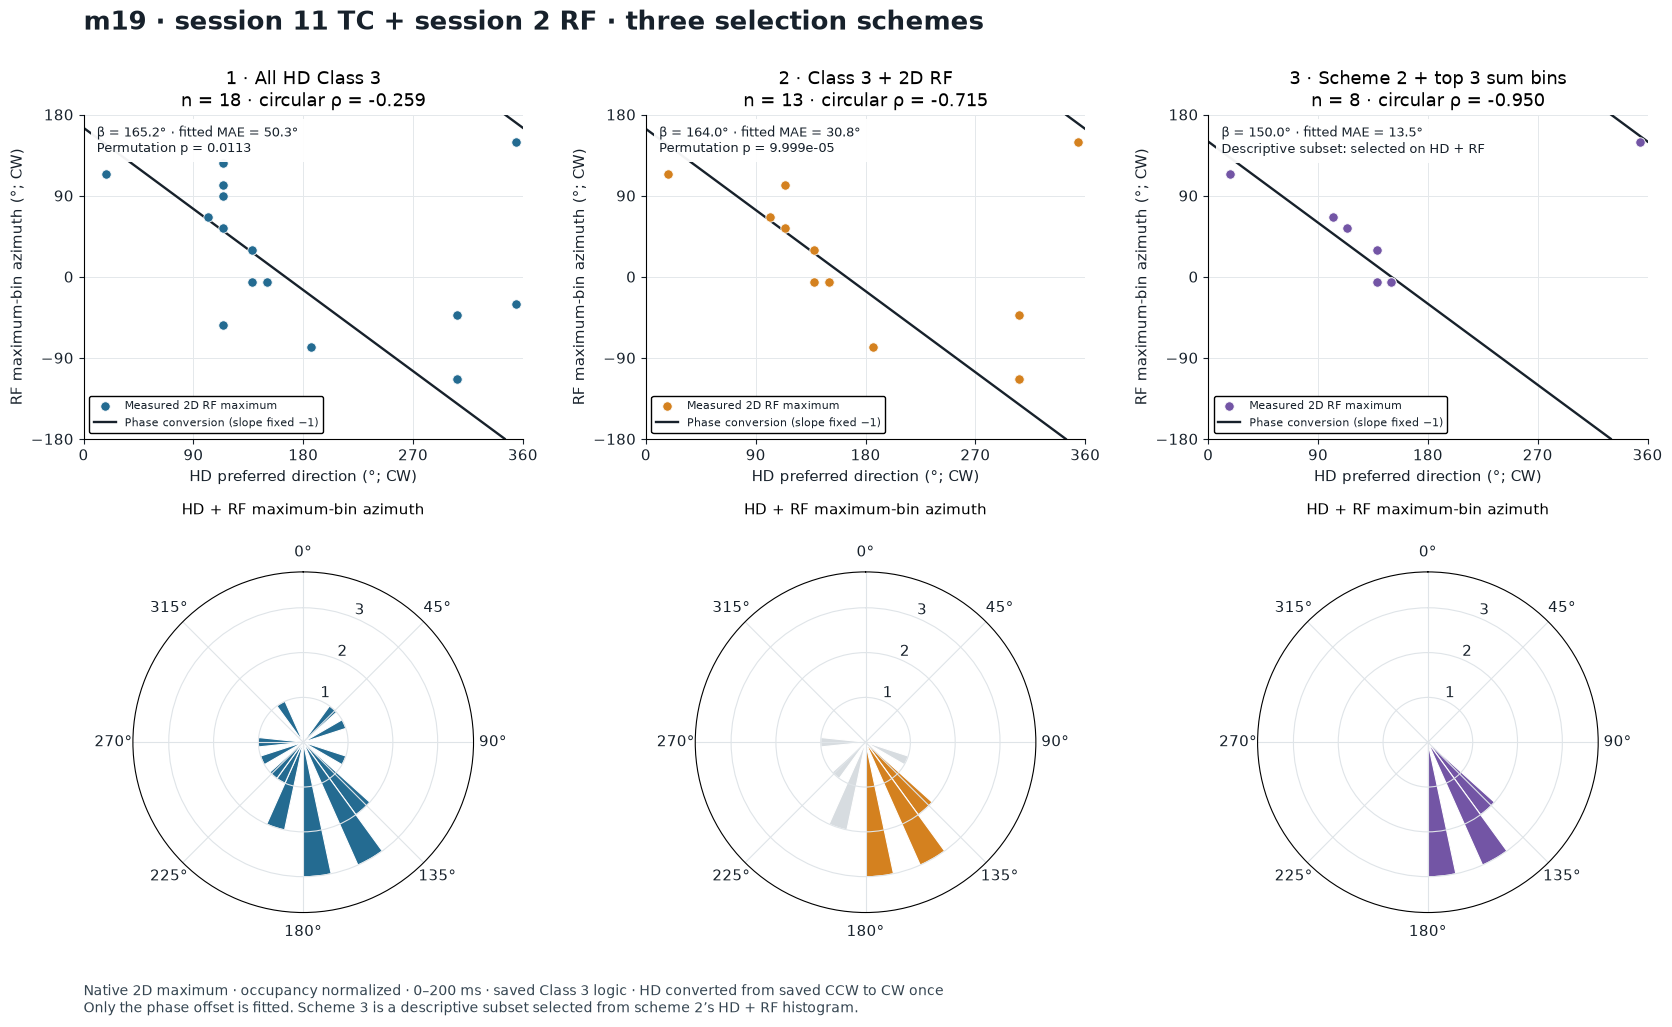

In [5]:
fig = plt.figure(figsize=(17, 10.5), facecolor='white')
grid = fig.add_gridspec(2, 3, height_ratios=[1, 1.05], hspace=.40, wspace=.28)
colors = ['#246b91', '#d4811f', '#7355a5']
query = np.linspace(0., 360., 1441)
max_count = max(np.histogram(p.hd_plus_rf_deg % 360, edges)[0].max() for p in schemes.values())
for column, ((name, pairs), color) in enumerate(zip(schemes.items(), colors)):
    result = results[name]
    ax = fig.add_subplot(grid[0, column])
    curve = predict_circular_conversion(query, result['beta_deg'])['rf_ego_deg']
    curve = np.asarray(curve).copy()
    curve[np.r_[False, np.abs(np.diff(curve)) > 180]] = np.nan
    ax.scatter(pairs.hd_preferred_deg, pairs.rf_ego_deg, s=46, color=color,
               edgecolor='white', linewidth=.6, zorder=3, label='Measured 2D RF maximum')
    ax.plot(query, curve, color='#17212b', lw=1.7, label='Phase conversion (slope fixed −1)')
    ax.set(xlim=(0, 360), ylim=(-180, 180), xticks=[0, 90, 180, 270, 360],
           yticks=[-180, -90, 0, 90, 180], xlabel='HD preferred direction (°; CW)',
           ylabel='RF maximum-bin azimuth (°; CW)', title=f"{labels[name]}\nn = {result['n']} · circular ρ = {result['rho']:.3f}")
    p = result['permutation_p']
    note = f"β = {result['beta_deg']:.1f}° · fitted MAE = {result['mae_deg']:.1f}°"
    note += f"\nPermutation p = {p:.4g}" if p is not None else '\nDescriptive subset: selected on HD + RF'
    ax.text(.03, .97, note, ha='left', va='top', transform=ax.transAxes, fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', alpha=.95))
    ax.grid(color='#e4e8eb', lw=.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='lower left', fontsize=8, facecolor='white', framealpha=1)
    polar = fig.add_subplot(grid[1, column], projection='polar')
    counts, _ = np.histogram(pairs.hd_plus_rf_deg % 360, edges)
    bar_colors = [color if name == 'scheme1' or i in top_bins else '#d7dce0' for i in range(polar_bins)]
    polar.bar(np.deg2rad((edges[:-1] + edges[1:]) / 2), counts,
              width=np.deg2rad(12), color=bar_colors, edgecolor='white', linewidth=.8)
    polar.set_theta_zero_location('N')
    polar.set_theta_direction(-1)
    polar.set_ylim(0, max_count + .8)
    polar.yaxis.set_major_locator(MaxNLocator(integer=True))
    polar.grid(color='#dfe4e8')
    polar.set_title('HD + RF maximum-bin azimuth', pad=22, fontsize=11)
fig.suptitle('m19 · session 11 TC + session 2 RF · three selection schemes',
             fontsize=19, fontweight='bold', x=.06, ha='left', y=.98)
fig.text(.06, .025, 'Native 2D maximum · occupancy normalized · 0–200 ms · saved Class 3 logic · HD converted from saved CCW to CW once\n'
                   'Only the phase offset is fitted. Scheme 3 is a descriptive subset selected from scheme 2’s HD + RF histogram.',
         fontsize=10, color='#354551')
fig.subplots_adjust(left=.06, right=.98, top=.88, bottom=.12)
fig.savefig(output / 'three_schemes.png', dpi=180, facecolor='white', transparent=False)
plt.show()

## Save the conversion parameters

The JSON and dense angle grid make the conversion available to the population video without repeating the correlation analysis. A 360° input turn returns to the same predicted RF direction.

In [6]:
models = {}
for name, pairs in schemes.items():
    result = results[name]
    model = {'method': 'reversed_circular_phase', 'scheme': name,
             'n': result['n'], 'beta_deg': result['beta_deg'], 'conversion_slope': -1,
             'rho_circular': result['rho'], 'permutation_p': result['permutation_p'],
             'fit_mae_deg': result['mae_deg'],
             'selected_on_sum': name == 'scheme3', 'provenance': provenance,
             'selected_units': pairs.unit_id.astype(int).tolist(),
             'angle_convention': 'HD and RF ego clockwise; RF allo = wrap360(HD + RF ego)',
             'equation': 'RF ego = wrap180(beta - HD); RF allo = beta'}
    models[name] = model
    (output / f'{name}_conversion.json').write_text(json.dumps(model, indent=2, allow_nan=False) + '\n')
    predicted = predict_circular_conversion(query, result['beta_deg'])
    pd.DataFrame({'hd_deg': query, **predicted}).to_csv(output / f'{name}_conversion_grid.csv', index=False)
(output / 'conversion_models.json').write_text(json.dumps(models, indent=2, allow_nan=False) + '\n')
print(f'Saved comparison, unit lists, polar-bin ranks, and conversions to {output.resolve()}')

Saved comparison, unit lists, polar-bin ranks, and conversions to /home/kai/Developer/rfmapping/output/hd_rf_schemes/m19_260827_hd11_rf2
